In [168]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [169]:
df = pd.read_csv("loan_approval_data.csv")

In [170]:
df


,Applicant_ID,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
0,1.0,2199400.0,1416300.0,Salaried,21.0,Married,1.0,640.0,5.0,0.164,100800.0,167000.0,355000.0,48.0,Car,Rural,Not Graduate,Male,Private,Yes
1,2.0,109100.0,66100.0,Contract,51.0,Married,1.0,733.0,5.0,0.458,61300.0,279000.0,254000.0,48.0,Home,Urban,Graduate,Female,Unemployed,No
2,3.0,10500.0,6800.0,Unemployed,43.0,Married,4.0,474.0,1.0,0.384,3800.0,1612000.0,647000.0,60.0,Personal,Rural,Graduate,Male,Private,No
3,4.0,22400.0,11500.0,Self-employed,23.0,Married,2.0,533.0,2.0,0.603,4100.0,24200000.0,13600000.0,180.0,Education,Urban,Graduate,Female,Government,No
4,5.0,10000.0,6300.0,Salaried,45.0,Single,2.0,739.0,5.0,0.283,134700.0,3707000.0,1806000.0,60.0,Home,Semiurban,Not Graduate,Male,Unemployed,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
999995,999996.0,95300.0,3700.0,Contract,27.0,Married,2.0,692.0,4.0,0.305,89200.0,61469000.0,41334000.0,60.0,Business,Rural,Not Graduate,Male,Unemployed,No
999996,999997.0,40900.0,11000.0,Salaried,33.0,Single,1.0,592.0,5.0,0.200,77600.0,976000.0,669000.0,60.0,Personal,Rural,Graduate,Male,MNC,No
999997,999998.0,232600.0,73300.0,Salaried,30.0,Single,1.0,615.0,0.0,0.210,371200.0,3000.0,315000.0,48.0,Personal,Rural,Not Graduate,Female,Unemployed,Yes
999998,999999.0,10000.0,6100.0,Salaried,26.0,Married,1.0,792.0,2.0,0.218,17400.0,828000.0,809000.0,60.0,Education,Urban,Graduate,Male,Government,Yes


In [171]:
df.head()
df.info()
df.isnull().sum()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 20 columns):
 #   Column              Non-Null Count    Dtype  
---  ------              --------------    -----  
 0   Applicant_ID        1000000 non-null  float64
 1   Applicant_Income    1000000 non-null  float64
 2   Coapplicant_Income  1000000 non-null  float64
 3   Employment_Status   1000000 non-null  object 
 4   Age                 1000000 non-null  float64
 5   Marital_Status      1000000 non-null  object 
 6   Dependents          1000000 non-null  float64
 7   Credit_Score        1000000 non-null  float64
 8   Existing_Loans      1000000 non-null  float64
 9   DTI_Ratio           1000000 non-null  float64
 10  Savings             1000000 non-null  float64
 11  Collateral_Value    1000000 non-null  float64
 12  Loan_Amount         1000000 non-null  float64
 13  Loan_Term           1000000 non-null  float64
 14  Loan_Purpose        1000000 non-null  object 
 15  Property_Area   

,Applicant_ID,Applicant_Income,Coapplicant_Income,Age,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term
count,1000000.000000,1.000000e+06,1.000000e+06,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1.000000e+06,1.000000e+06,1.000000e+06,1000000.000000
mean,500000.500000,1.119846e+05,4.487193e+04,38.164578,1.541151,644.899408,2.169674,0.342000,3.412366e+05,7.367127e+06,5.917947e+06,98.924886
std,288675.278933,2.114856e+05,1.011383e+05,9.588087,1.185989,83.480532,1.748855,0.175015,1.731197e+06,3.033631e+07,2.109977e+07,90.923769
min,1.000000,1.000000e+04,0.000000e+00,21.000000,0.000000,300.000000,0.000000,0.050000,1.000000e+03,0.000000e+00,1.000000e+04,6.000000
25%,250000.750000,2.140000e+04,6.200000e+03,31.000000,1.000000,589.000000,1.000000,0.214000,1.460000e+04,2.960000e+05,3.570000e+05,36.000000
50%,500000.500000,5.090000e+04,1.650000e+04,38.000000,1.000000,645.000000,2.000000,0.332000,5.200000e+04,1.180000e+06,1.207000e+06,60.000000
75%,750000.250000,1.195000e+05,4.470000e+04,45.000000,2.000000,701.000000,3.000000,0.456000,1.916000e+05,4.469000e+06,4.054000e+06,120.000000
max,1000000.000000,1.000000e+07,5.000000e+06,65.000000,4.000000,900.000000,6.000000,0.900000,1.000000e+08,1.000000e+09,5.000000e+08,360.000000


# Handle Missing Values

In [172]:
categorical_cols = df.select_dtypes(include=["object"]).columns
numerical_cols = df.select_dtypes(include=["number"]).columns

In [173]:
from sklearn.impute import SimpleImputer

num_imp = SimpleImputer(strategy="mean")
df[numerical_cols] = num_imp.fit_transform(df[numerical_cols])

In [174]:
cat_imp = SimpleImputer(strategy="most_frequent")
df[categorical_cols] = cat_imp.fit_transform(df[categorical_cols])

In [175]:
df.head()

,Applicant_ID,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
0,1.0,2199400.0,1416300.0,Salaried,21.0,Married,1.0,640.0,5.0,0.164,100800.0,167000.0,355000.0,48.0,Car,Rural,Not Graduate,Male,Private,Yes
1,2.0,109100.0,66100.0,Contract,51.0,Married,1.0,733.0,5.0,0.458,61300.0,279000.0,254000.0,48.0,Home,Urban,Graduate,Female,Unemployed,No
2,3.0,10500.0,6800.0,Unemployed,43.0,Married,4.0,474.0,1.0,0.384,3800.0,1612000.0,647000.0,60.0,Personal,Rural,Graduate,Male,Private,No
3,4.0,22400.0,11500.0,Self-employed,23.0,Married,2.0,533.0,2.0,0.603,4100.0,24200000.0,13600000.0,180.0,Education,Urban,Graduate,Female,Government,No
4,5.0,10000.0,6300.0,Salaried,45.0,Single,2.0,739.0,5.0,0.283,134700.0,3707000.0,1806000.0,60.0,Home,Semiurban,Not Graduate,Male,Unemployed,Yes


In [176]:
# Remove Applicant Id
df = df.drop("Applicant_ID", axis=1)

In [177]:
# Remove only extreme outliers — use wider 3x IQR instead of 1.5x
# This preserves realistic wide-range Indian rupee values
numeric_cols = ['Applicant_Income', 'Loan_Amount', 'Savings', 'Collateral_Value', 'DTI_Ratio']
before = len(df)
for col in numeric_cols:
    Q1  = df[col].quantile(0.05)   # use 5th percentile instead of 25th
    Q3  = df[col].quantile(0.95)   # use 95th percentile instead of 75th
    IQR = Q3 - Q1
    df  = df[(df[col] >= Q1 - 3 * IQR) & (df[col] <= Q3 + 3 * IQR)]
after = len(df)
print(f"Removed {before - after} outliers ({round((before-after)/before*100, 1)}%), kept {after} rows")

Removed 24200 outliers (2.4%), kept 975800 rows


# EDA - exploratory data analysis

Text(0.5, 1.0, 'Is Loan approved or not?')

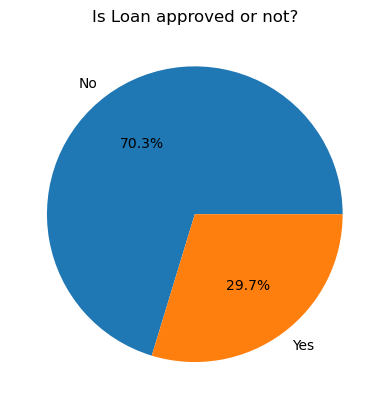

In [178]:
# how balanced our classes are?

classes_count = df["Loan_Approved"].value_counts()

plt.pie(classes_count, labels=["No", "Yes"], autopct="%1.1f%%")
plt.title("Is Loan approved or not?")

[Text(0, 0, '653602'), Text(0, 0, '322198')]

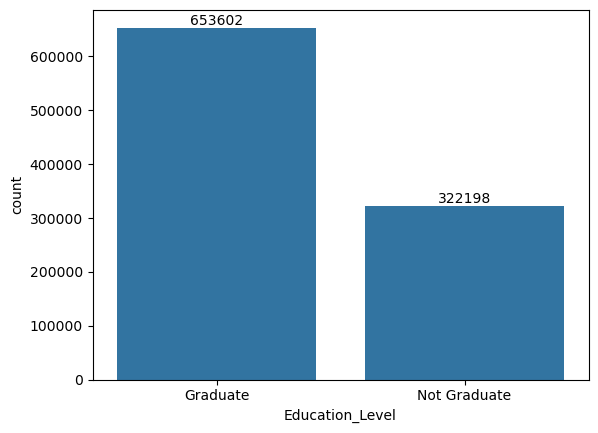

In [179]:
# analyze categories

# gender_cnt = df["Gender"].value_counts()
# ax = sns.barplot(gender_cnt)
# ax.bar_label(ax.containers[0])

edu_cnt = df["Education_Level"].value_counts()
ax = sns.barplot(edu_cnt)
ax.bar_label(ax.containers[0])

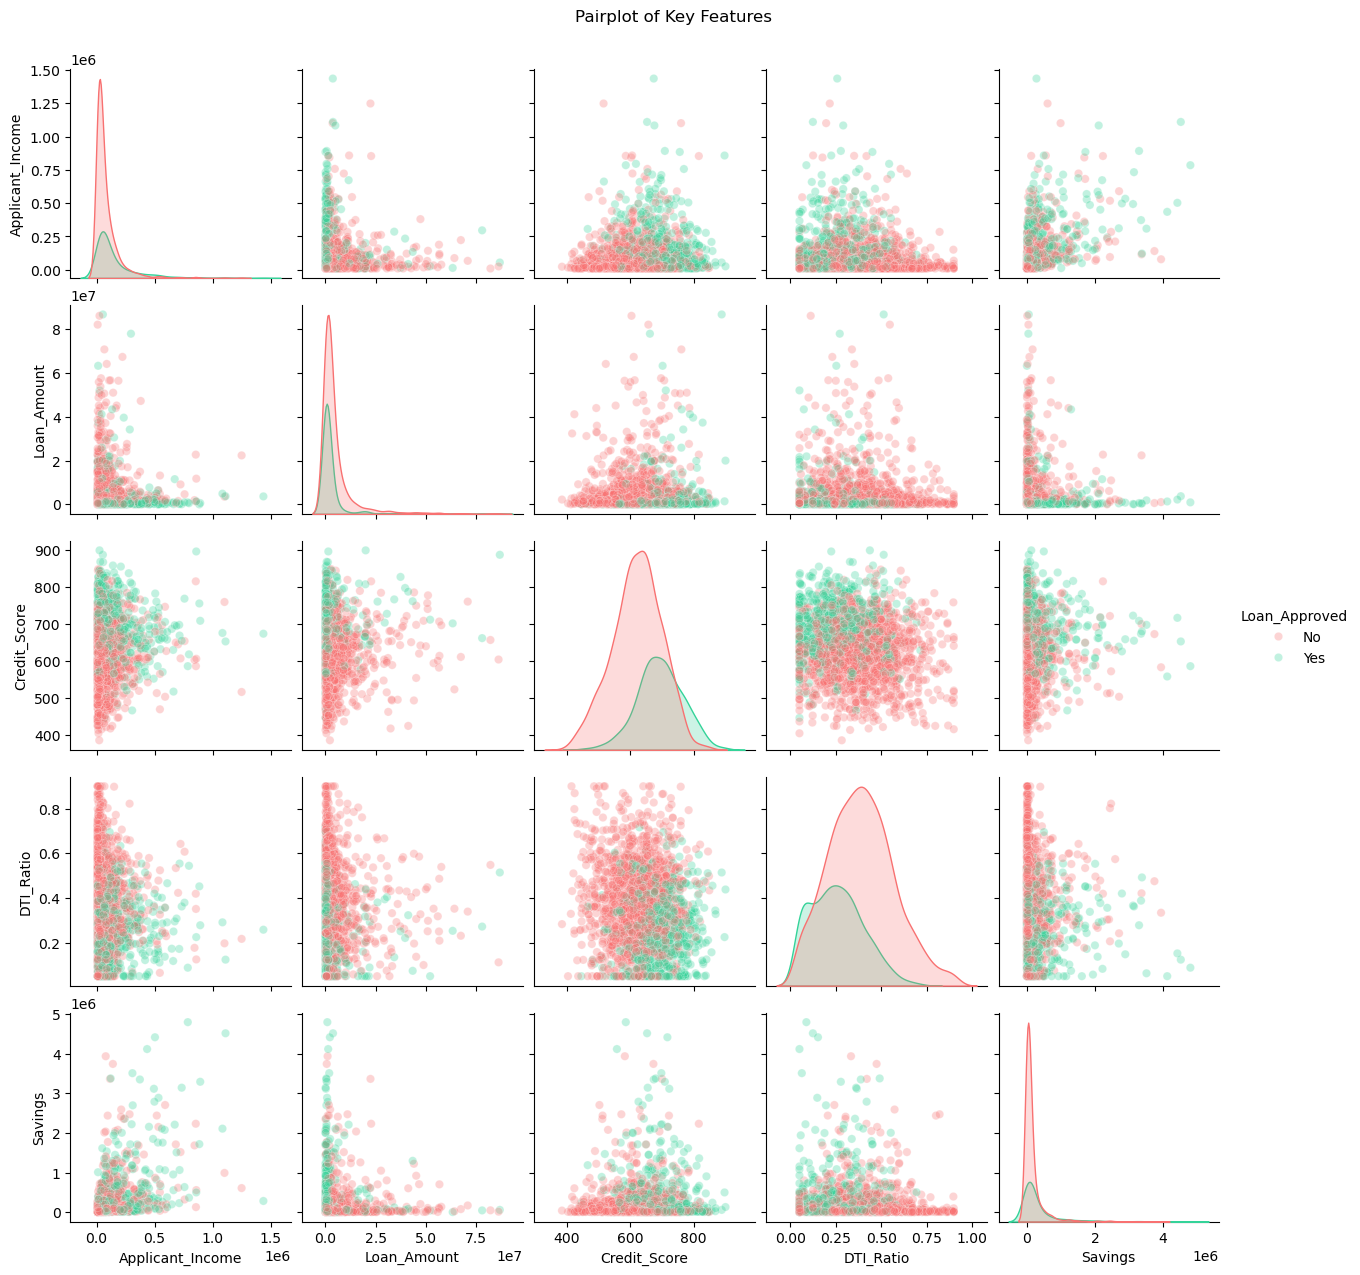

In [180]:
sample = df.sample(2000, random_state=42)  # sample for speed
sns.pairplot(
    sample[['Applicant_Income','Loan_Amount','Credit_Score','DTI_Ratio','Savings','Loan_Approved']],
    hue='Loan_Approved',
    palette=['#f87171','#34d399'],
    plot_kws={'alpha': 0.3}
)
plt.suptitle("Pairplot of Key Features", y=1.02)
plt.show()

<Axes: xlabel='Coapplicant_Income', ylabel='Count'>

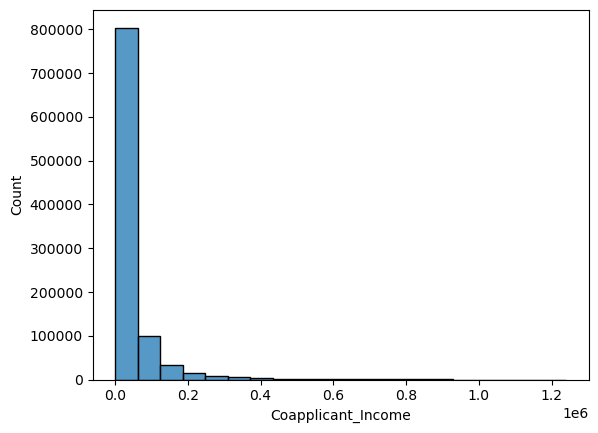

In [181]:
sns.histplot(
    data = df,
    x = "Coapplicant_Income",
    bins=20
)

<Axes: xlabel='Credit_Score', ylabel='Count'>

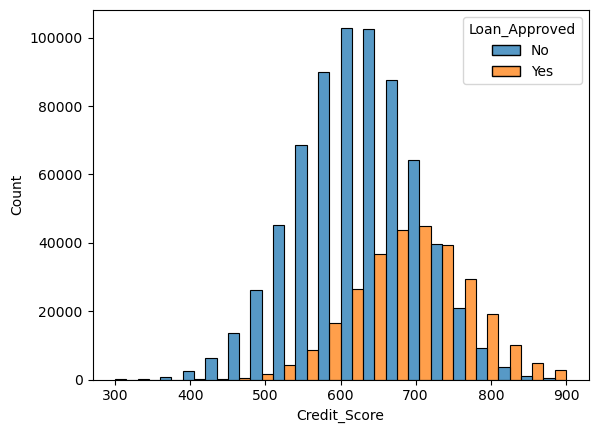

In [182]:
# Credit Score with Loan Approved

sns.histplot(
    data=df,
    x="Credit_Score",
    hue="Loan_Approved",
    bins=20,
    multiple="dodge"
)

# Encoding

In [183]:
df.head()
df.columns
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 975800 entries, 1 to 999999
Data columns (total 19 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   Applicant_Income    975800 non-null  float64
 1   Coapplicant_Income  975800 non-null  float64
 2   Employment_Status   975800 non-null  object 
 3   Age                 975800 non-null  float64
 4   Marital_Status      975800 non-null  object 
 5   Dependents          975800 non-null  float64
 6   Credit_Score        975800 non-null  float64
 7   Existing_Loans      975800 non-null  float64
 8   DTI_Ratio           975800 non-null  float64
 9   Savings             975800 non-null  float64
 10  Collateral_Value    975800 non-null  float64
 11  Loan_Amount         975800 non-null  float64
 12  Loan_Term           975800 non-null  float64
 13  Loan_Purpose        975800 non-null  object 
 14  Property_Area       975800 non-null  object 
 15  Education_Level     975800 non-null  ob

In [184]:
# Label Encoding

from sklearn.preprocessing import LabelEncoder, OneHotEncoder

le = LabelEncoder()
df["Education_Level"] = le.fit_transform(df["Education_Level"])
df["Loan_Approved"] = le.fit_transform(df["Loan_Approved"])


In [185]:
# OneHotEncoding

cols = ["Employment_Status", "Marital_Status", "Loan_Purpose", "Property_Area", "Gender", "Employer_Category"]

ohe = OneHotEncoder(drop="first", sparse_output=False, handle_unknown="ignore")

encoded = ohe.fit_transform(df[cols])

encoded_df = pd.DataFrame(encoded, columns=ohe.get_feature_names_out(cols), index=df.index)

df = pd.concat([df.drop(columns=cols), encoded_df], axis=1)

In [186]:
# Feature engineering — add ratio features to fix multicollinearity
df['Collateral_Ratio']  = df['Collateral_Value'] / (df['Loan_Amount'] + 1)
df['Income_Loan_Ratio'] = df['Applicant_Income'] / (df['Loan_Amount'] + 1)
df['DTI_Ratio_sq']      = df['DTI_Ratio'] ** 2
df['Credit_Score_sq']   = df['Credit_Score'] ** 2

# Drop raw Collateral_Value — replaced by ratio
df = df.drop(columns=['Collateral_Value', 'Credit_Score', 'DTI_Ratio'])
# Drop Income_Loan_Ratio — redundant with Applicant_Income, causes negative coefficient
df = df.drop(columns=['Income_Loan_Ratio'])
print("Shape after drop:", df.shape)

print("New columns:", list(df.columns))
print("Shape:", df.shape)

Shape after drop: (975800, 28)
New columns: ['Applicant_Income', 'Coapplicant_Income', 'Age', 'Dependents', 'Existing_Loans', 'Savings', 'Loan_Amount', 'Loan_Term', 'Education_Level', 'Loan_Approved', 'Employment_Status_Salaried', 'Employment_Status_Self-employed', 'Employment_Status_Unemployed', 'Marital_Status_Single', 'Loan_Purpose_Car', 'Loan_Purpose_Education', 'Loan_Purpose_Home', 'Loan_Purpose_Personal', 'Property_Area_Semiurban', 'Property_Area_Urban', 'Gender_Male', 'Employer_Category_Government', 'Employer_Category_MNC', 'Employer_Category_Private', 'Employer_Category_Unemployed', 'Collateral_Ratio', 'DTI_Ratio_sq', 'Credit_Score_sq']
Shape: (975800, 28)


In [187]:
df.head()

,Applicant_Income,Coapplicant_Income,Age,Dependents,Existing_Loans,Savings,Loan_Amount,Loan_Term,Education_Level,Loan_Approved,...,Property_Area_Semiurban,Property_Area_Urban,Gender_Male,Employer_Category_Government,Employer_Category_MNC,Employer_Category_Private,Employer_Category_Unemployed,Collateral_Ratio,DTI_Ratio_sq,Credit_Score_sq
1,109100.0,66100.0,51.0,1.0,5.0,61300.0,254000.0,48.0,0,0,...,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.098421,0.209764,537289.0
2,10500.0,6800.0,43.0,4.0,1.0,3800.0,647000.0,60.0,0,0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,2.491495,0.147456,224676.0
3,22400.0,11500.0,23.0,2.0,2.0,4100.0,13600000.0,180.0,0,0,...,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.779412,0.363609,284089.0
4,10000.0,6300.0,45.0,2.0,5.0,134700.0,1806000.0,60.0,1,1,...,1.0,0.0,1.0,0.0,0.0,0.0,1.0,2.052601,0.080089,546121.0
5,10000.0,4600.0,40.0,2.0,2.0,1000.0,3090000.0,120.0,1,0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.352427,0.100489,312481.0


# Correlation Heatmap

<Axes: >

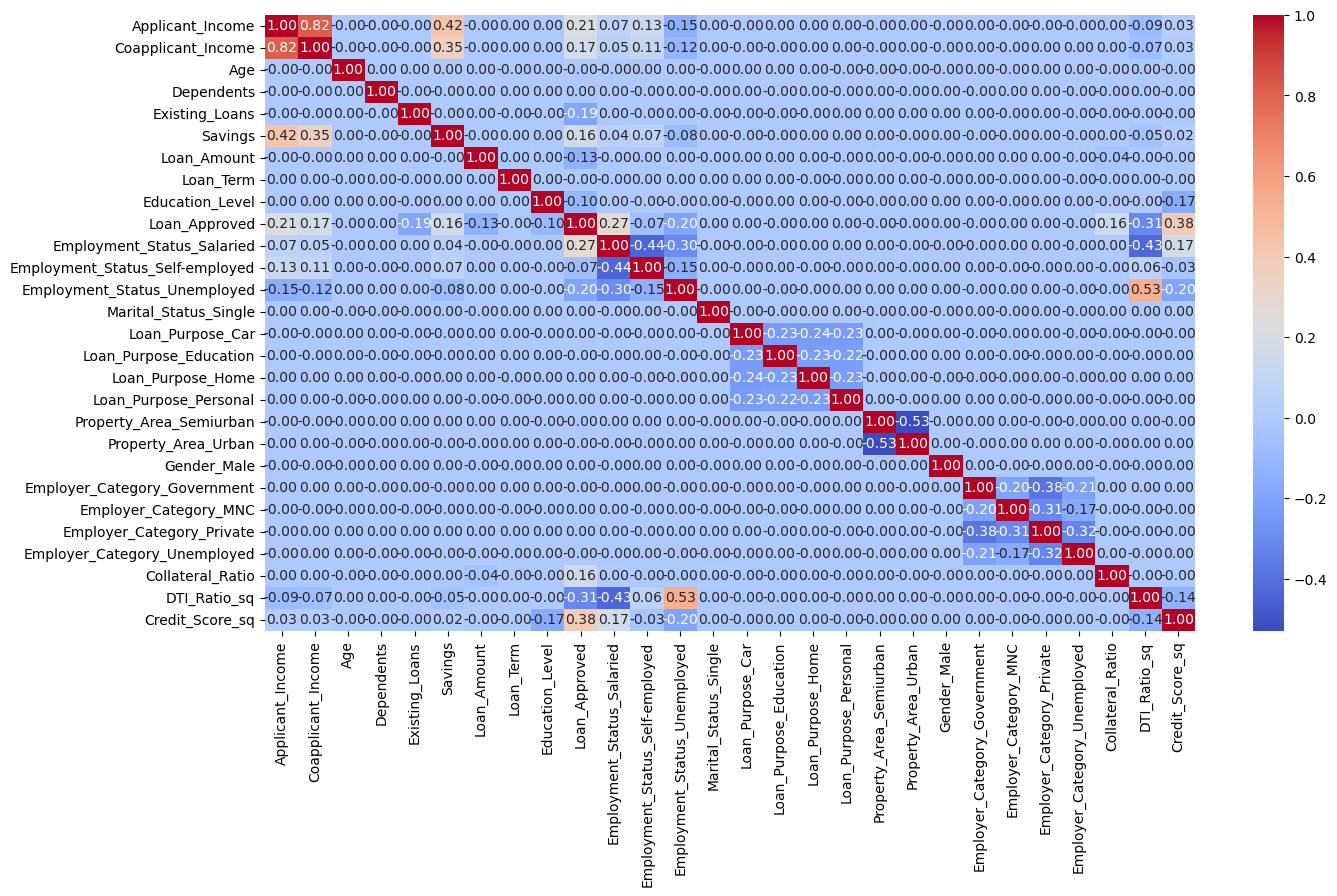

In [188]:
num_cols = df.select_dtypes(include="number")
corr_matrix = num_cols.corr()

plt.figure(figsize=(15, 8))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)


In [189]:
df.to_csv("Processed_loan_approval_data.csv", index=False)
print("Saved! Shape:", df.shape)
print("\nCorrelation with Loan_Approved:")
print(df.corr()['Loan_Approved'].sort_values())

Saved! Shape: (975800, 28)

Correlation with Loan_Approved:
DTI_Ratio_sq                      -0.313287
Employment_Status_Unemployed      -0.200695
Existing_Loans                    -0.190732
Loan_Amount                       -0.133268
Education_Level                   -0.102589
Employment_Status_Self-employed   -0.065985
Loan_Term                         -0.001713
Age                               -0.001512
Employer_Category_Unemployed      -0.000772
Loan_Purpose_Education            -0.000426
Employer_Category_Government      -0.000319
Property_Area_Urban               -0.000248
Property_Area_Semiurban           -0.000109
Marital_Status_Single              0.000355
Loan_Purpose_Home                  0.000377
Employer_Category_Private          0.000532
Loan_Purpose_Personal              0.000584
Gender_Male                        0.000884
Loan_Purpose_Car                   0.001299
Dependents                         0.001542
Employer_Category_MNC              0.001838
Collateral_Ratio